# Training Convergence — Reward over Episodes
Toont hoe de training en eval reward zich ontwikkelen per episode voor alle methoden in een experiment run.

In [54]:
# ── Configuration ──────────────────────────────────────────────────────
EXPERIMENT_DIR = "../../results/runs/loan_app/earth_d/FINAL_42"
""

# Smoothing window for moving average (set to 1 for no smoothing)
SMOOTH_WINDOW = 5

In [55]:
import os, re

# ── Resolve EXPERIMENT_DIR: auto-pick latest timestamp subfolder ──────
# If the path already ends with a timestamp folder (YYYYMMDD_HHMMSS), use as-is.
# Otherwise, scan for timestamp subfolders and pick the latest one.
def resolve_experiment_dir(path):
    path = path.rstrip("/")
    basename = os.path.basename(path)
    # Check if the path already ends with a timestamp
    if re.match(r"^\d{8}_\d{6}$", basename):
        return path
    # Look for timestamp subfolders
    if not os.path.isdir(path):
        raise FileNotFoundError(f"Directory not found: {path}")
    ts_dirs = sorted(
        [d for d in os.listdir(path)
         if os.path.isdir(os.path.join(path, d)) and re.match(r"^\d{8}_\d{6}$", d)],
    )
    if not ts_dirs:
        # No timestamp subfolders found — use the path as-is
        return path
    latest = ts_dirs[-1]
    print(f"Auto-selected latest run: {latest}")
    return os.path.join(path, latest)

EXPERIMENT_DIR = resolve_experiment_dir(EXPERIMENT_DIR)

In [56]:
import os, glob
import numpy as np
import matplotlib.pyplot as plt

# ── Discover methods and load reward data ─────────────────────────────
methods = {}

for entry in sorted(os.listdir(EXPERIMENT_DIR)):
    entry_path = os.path.join(EXPERIMENT_DIR, entry)
    if not os.path.isdir(entry_path):
        continue

    # Look for training_summary.txt directly or one level deeper
    summary_path = os.path.join(entry_path, "training_summary.txt")
    if not os.path.exists(summary_path):
        subdirs = [d for d in os.listdir(entry_path)
                   if os.path.isdir(os.path.join(entry_path, d))]
        for sd in sorted(subdirs):
            summary_path = os.path.join(entry_path, sd, "training_summary.txt")
            if os.path.exists(summary_path):
                entry_path = os.path.join(entry_path, sd)
                break

    if not os.path.exists(summary_path):
        continue

    # Parse episode rewards and eval rewards from training_summary.txt
    train_rewards = []
    eval_rewards = []
    section = None

    with open(summary_path) as f:
        for line in f:
            line = line.strip()
            if line == "Episode Rewards:":
                section = "train"
                continue
            elif line == "Evaluation Rewards:":
                section = "eval"
                continue
            elif line == "" or line.startswith("="):
                continue

            if section == "train" and line.startswith("Episode "):
                try:
                    val = float(line.split(":")[1].strip())
                    train_rewards.append(val)
                except (ValueError, IndexError):
                    pass
            elif section == "eval" and line.startswith("Eval "):
                try:
                    val = float(line.split(":")[1].strip())
                    eval_rewards.append(val)
                except (ValueError, IndexError):
                    pass

    if train_rewards:
        methods[entry] = {
            "train": train_rewards,
            "eval": eval_rewards,
        }

print(f"Found {len(methods)} methods:")
for name, data in methods.items():
    print(f"  {name}: {len(data['train'])} train episodes, {len(data['eval'])} eval episodes")
    print(f"    Train reward: {data['train'][0]:.0f} → {data['train'][-1]:.0f} (best: {max(data['train']):.0f})")
    if data['eval']:
        print(f"    Eval reward:  {data['eval'][0]:.0f} → {data['eval'][-1]:.0f} (best: {max(data['eval']):.0f})")

Found 2 methods:
  mappo_parallel: 40 train episodes, 40 eval episodes
    Train reward: -4053 → -36393 (best: -4053)
    Eval reward:  -36323 → -36346 (best: -36235)
  mappo_parallel_comm: 40 train episodes, 40 eval episodes
    Train reward: -4053 → -8767 (best: -4053)
    Eval reward:  -36336 → -9579 (best: -9579)


In [57]:
# ── Helper: moving average ────────────────────────────────────────────
def smooth(values, window):
    if window <= 1 or len(values) < window:
        return values
    kernel = np.ones(window) / window
    # Pad to avoid shrinking
    padded = np.pad(values, (window // 2, window - 1 - window // 2), mode='edge')
    return np.convolve(padded, kernel, mode='valid')

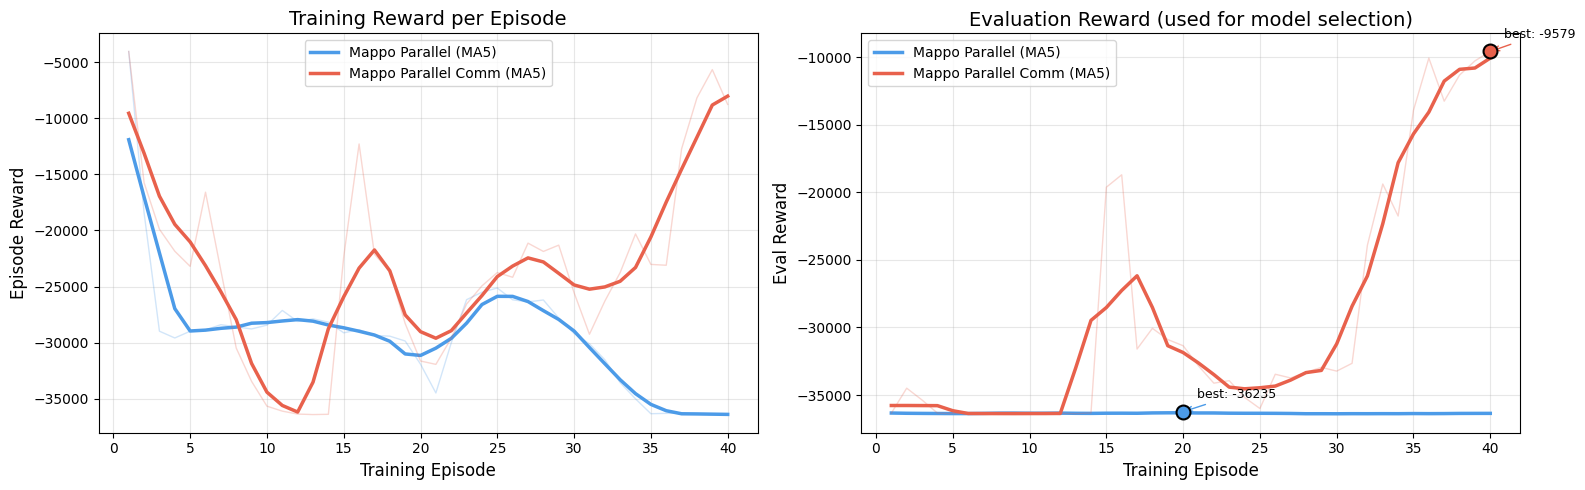

In [58]:
# ── Plot: Training reward per episode ─────────────────────────────────
# Auto-assign colors and labels based on method names
_color_palette = ["#4C9BE8", "#E8614C", "#2ECC71", "#F39C12", "#9B59B6", "#1ABC9C", "#E74C3C", "#3498DB"]
_method_names = sorted(methods.keys())
colors = {}
labels = {}
for i, name in enumerate(_method_names):
    if "baseline" in name:
        colors[name] = "#888888"
    elif "comm" in name:
        colors[name] = "#E8614C"
    else:
        colors[name] = "#4C9BE8"
    # Pretty label
    label = name.replace("_", " ").replace("baseline ", "BL ").title()
    labels[name] = label

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: Training rewards
ax = axes[0]
for name, data in methods.items():
    rewards = np.array(data["train"])
    episodes = np.arange(1, len(rewards) + 1)
    color = colors.get(name, "#333")
    label = labels.get(name, name)

    ax.plot(episodes, rewards, alpha=0.25, color=color, linewidth=1)
    if SMOOTH_WINDOW > 1:
        ax.plot(episodes, smooth(rewards, SMOOTH_WINDOW), color=color,
                linewidth=2.5, label=f"{label} (MA{SMOOTH_WINDOW})")
    else:
        ax.plot(episodes, rewards, color=color, linewidth=2, label=label)

ax.set_xlabel("Training Episode", fontsize=12)
ax.set_ylabel("Episode Reward", fontsize=12)
ax.set_title("Training Reward per Episode", fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Right: Evaluation rewards
ax = axes[1]
for name, data in methods.items():
    if not data["eval"]:
        continue
    rewards = np.array(data["eval"])
    # Eval happens at eval_freq intervals, map to correct episodes
    n_train = len(data["train"])
    n_eval = len(rewards)
    eval_freq = max(1, n_train // n_eval) if n_eval > 0 else 1
    episodes = np.arange(eval_freq, n_train + 1, eval_freq)[:n_eval]

    color = colors.get(name, "#333")
    label = labels.get(name, name)

    ax.plot(episodes, rewards, alpha=0.25, color=color, linewidth=1)
    if SMOOTH_WINDOW > 1 and len(rewards) >= SMOOTH_WINDOW:
        ax.plot(episodes, smooth(rewards, SMOOTH_WINDOW), color=color,
                linewidth=2.5, label=f"{label} (MA{SMOOTH_WINDOW})")
    else:
        ax.plot(episodes, rewards, color=color, linewidth=2, label=label)

    # Mark best eval
    best_idx = np.argmax(rewards)
    ax.scatter(episodes[best_idx], rewards[best_idx], color=color, s=100,
               zorder=5, edgecolors="black", linewidths=1.5)
    ax.annotate(f"best: {rewards[best_idx]:.0f}",
                xy=(episodes[best_idx], rewards[best_idx]),
                xytext=(10, 10), textcoords="offset points", fontsize=9,
                arrowprops=dict(arrowstyle="->", color=color))

ax.set_xlabel("Training Episode", fontsize=12)
ax.set_ylabel("Eval Reward", fontsize=12)
ax.set_title("Evaluation Reward (used for model selection)", fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Operational Metrics per Eval Episode
Avg task waiting time, avg case waiting time, en case throughput (cycle time) over training episodes.
Gebaseerd op eval logs (dezelfde policy als de eval reward hierboven).

In [59]:
import re
import pandas as pd
from collections import defaultdict

# ── Parse eval logs per method → per-episode operational metrics ──────
# Uses working time if work_schedule module is available, else calendar time
try:
    import sys
    sys.path.insert(0, os.path.abspath(os.path.join(EXPERIMENT_DIR, '..', '..', '..', '..')))
    from src.environment.work_schedule import working_seconds_between
    USE_WORK_SCHEDULE = True
    print("✓ Using working_seconds_between (Mon-Fri 08:00-20:00)")
except ImportError:
    USE_WORK_SCHEDULE = False
    print("⚠ work_schedule not available, using calendar time")

DATE_COLS = ["case_open_time", "case_completed_time",
             "task_assigned_time", "task_started_time", "task_completed_time"]

eval_metrics = {}   # method_name → { ep_nr: { metric: [values across eval runs] } }

for method_name in methods:
    eval_dir = os.path.join(EXPERIMENT_DIR, method_name, "logs", "eval")
    if not os.path.isdir(eval_dir):
        # Try one level deeper
        for sd in os.listdir(os.path.join(EXPERIMENT_DIR, method_name)):
            candidate = os.path.join(EXPERIMENT_DIR, method_name, sd, "logs", "eval")
            if os.path.isdir(candidate):
                eval_dir = candidate
                break
    if not os.path.isdir(eval_dir):
        print(f"  {method_name}: no eval logs found")
        continue

    ep_data = defaultdict(lambda: {
        "task_wait_min": [], "case_wait_min": [], "case_throughput_min": []
    })

    for fname in sorted(os.listdir(eval_dir)):
        if not fname.endswith(".csv"):
            continue
        # Parse episode number: log_eval_ep{N}_e{eval_idx}_{timestamp}.csv
        m = re.match(r"log_eval_ep(\d+)_e(\d+)_", fname)
        if not m:
            continue
        ep_nr = int(m.group(1))

        df = pd.read_csv(os.path.join(eval_dir, fname), dtype={"task_volunteers": str})
        if df.empty:
            continue
        # Convert timestamp columns (mixed precision: some have nanos, some don't)
        for col in DATE_COLS:
            if col in df.columns:
                df[col] = pd.to_datetime(df[col], format="ISO8601", utc=True)

        # ── Task waiting time (per task) ──
        if USE_WORK_SCHEDULE:
            task_waits = df.apply(
                lambda r: working_seconds_between(r["task_assigned_time"], r["task_started_time"]),
                axis=1
            ) / 60.0
        else:
            task_waits = (df["task_started_time"] - df["task_assigned_time"]).dt.total_seconds() / 60.0
        avg_task_wait = task_waits.mean()

        # ── Case waiting time (sum of task waits per case, then average) ──
        df["_task_wait"] = task_waits
        case_waits = df.groupby("case_id")["_task_wait"].sum()
        avg_case_wait = case_waits.mean()

        # ── Case throughput / cycle time ──
        cases = df.groupby("case_id").agg(
            open_time=("case_open_time", "first"),
            completed_time=("case_completed_time", "first"),
        )
        if USE_WORK_SCHEDULE:
            case_cycle = cases.apply(
                lambda r: working_seconds_between(r["open_time"], r["completed_time"]),
                axis=1
            ) / 60.0
        else:
            case_cycle = (cases["completed_time"] - cases["open_time"]).dt.total_seconds() / 60.0
        avg_case_throughput = case_cycle.mean()

        ep_data[ep_nr]["task_wait_min"].append(avg_task_wait)
        ep_data[ep_nr]["case_wait_min"].append(avg_case_wait)
        ep_data[ep_nr]["case_throughput_min"].append(avg_case_throughput)

    # Average across eval runs per episode
    episodes_sorted = sorted(ep_data.keys())
    eval_metrics[method_name] = {
        "episodes": episodes_sorted,
        "task_wait": [np.mean(ep_data[e]["task_wait_min"]) for e in episodes_sorted],
        "case_wait": [np.mean(ep_data[e]["case_wait_min"]) for e in episodes_sorted],
        "case_throughput": [np.mean(ep_data[e]["case_throughput_min"]) for e in episodes_sorted],
    }
    print(f"  {method_name}: {len(episodes_sorted)} eval checkpoints, "
          f"task_wait {eval_metrics[method_name]['task_wait'][-1]:.1f} min (last), "
          f"case_throughput {eval_metrics[method_name]['case_throughput'][-1]:.1f} min (last)")

⚠ work_schedule not available, using calendar time
  mappo_parallel: 40 eval checkpoints, task_wait 200.1 min (last), case_throughput 1928.5 min (last)
  mappo_parallel_comm: 40 eval checkpoints, task_wait 2967.1 min (last), case_throughput 16683.9 min (last)


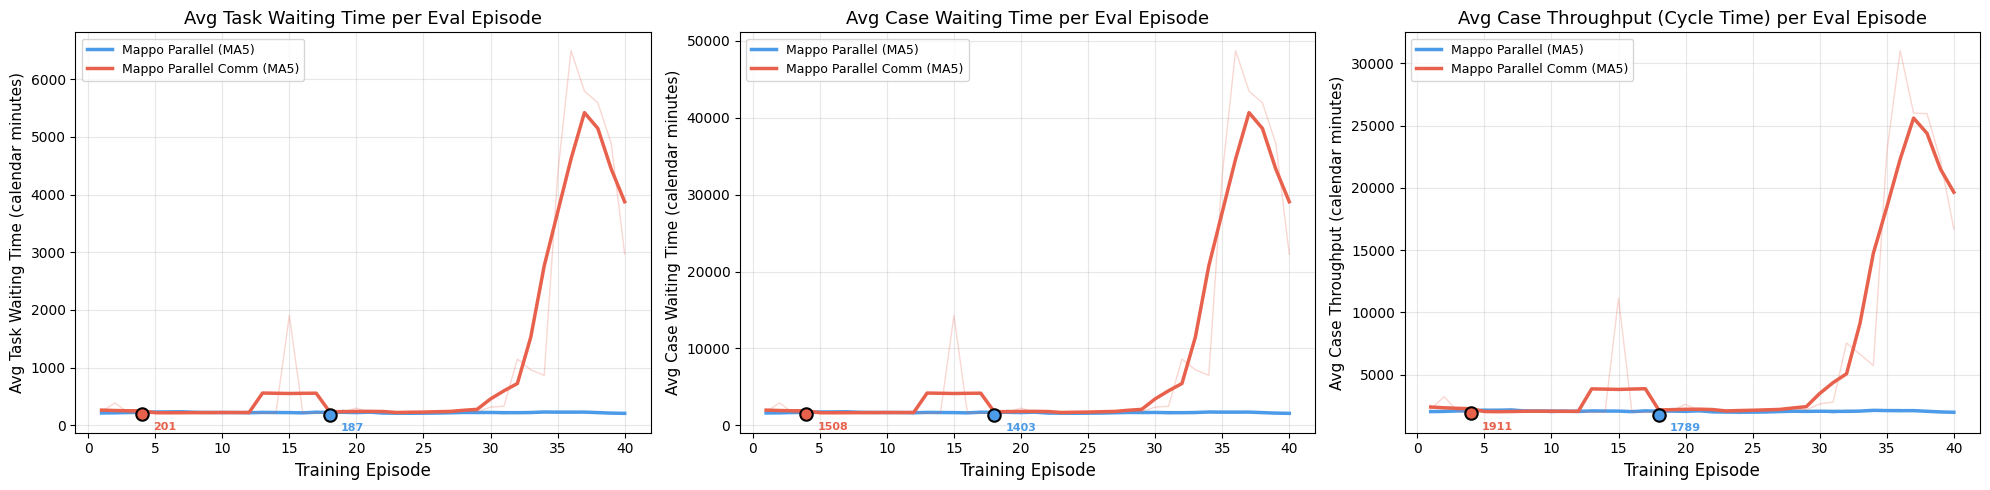

In [60]:
# ── Plot: Operational metrics over training episodes ──────────────────
time_unit = "working minutes" if USE_WORK_SCHEDULE else "calendar minutes"

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

plot_configs = [
    ("task_wait",       f"Avg Task Waiting Time ({time_unit})",    "Avg Task Waiting Time per Eval Episode"),
    ("case_wait",       f"Avg Case Waiting Time ({time_unit})",    "Avg Case Waiting Time per Eval Episode"),
    ("case_throughput", f"Avg Case Throughput ({time_unit})",       "Avg Case Throughput (Cycle Time) per Eval Episode"),
]

for ax, (metric_key, ylabel, title) in zip(axes, plot_configs):
    for method_name, mdata in eval_metrics.items():
        eps = np.array(mdata["episodes"])
        vals = np.array(mdata[metric_key])
        color = colors.get(method_name, "#333")
        label = labels.get(method_name, method_name)

        ax.plot(eps, vals, alpha=0.25, color=color, linewidth=1)
        if SMOOTH_WINDOW > 1 and len(vals) >= SMOOTH_WINDOW:
            ax.plot(eps, smooth(vals, SMOOTH_WINDOW), color=color,
                    linewidth=2.5, label=f"{label} (MA{SMOOTH_WINDOW})")
        else:
            ax.plot(eps, vals, color=color, linewidth=2, label=label)

        # Mark best (lowest) value
        best_idx = np.argmin(vals)
        ax.scatter(eps[best_idx], vals[best_idx], color=color, s=80,
                   zorder=5, edgecolors="black", linewidths=1.5)
        ax.annotate(f"{vals[best_idx]:.0f}",
                    xy=(eps[best_idx], vals[best_idx]),
                    xytext=(8, -12), textcoords="offset points", fontsize=8,
                    color=color, fontweight="bold")

    ax.set_xlabel("Training Episode", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [61]:
# ── Table: reward summary per method ──────────────────────────────────
import pandas as pd

rows = []
for name, data in methods.items():
    train = np.array(data["train"])
    row = {
        "method": labels.get(name, name),
        "n_episodes": len(train),
        "train_first": train[0],
        "train_last": train[-1],
        "train_best": train.max(),
        "train_mean": train.mean(),
    }
    if data["eval"]:
        ev = np.array(data["eval"])
        row["eval_best"] = ev.max()
        row["eval_best_ep"] = int((np.argmax(ev) + 1) * max(1, len(train) // len(ev)))
        row["eval_last"] = ev[-1]
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index("method")
print("=" * 100)
print("TRAINING SUMMARY")
print("=" * 100)
display(summary_df.round(0))

TRAINING SUMMARY


,n_episodes,train_first,train_last,train_best,train_mean,eval_best,eval_best_ep,eval_last
method,,,,,,,,
Mappo Parallel,40,-4053.0,-36393.0,-4053.0,-29199.0,-36235.0,20,-36346.0
Mappo Parallel Comm,40,-4053.0,-8767.0,-4053.0,-23545.0,-9579.0,40,-9579.0


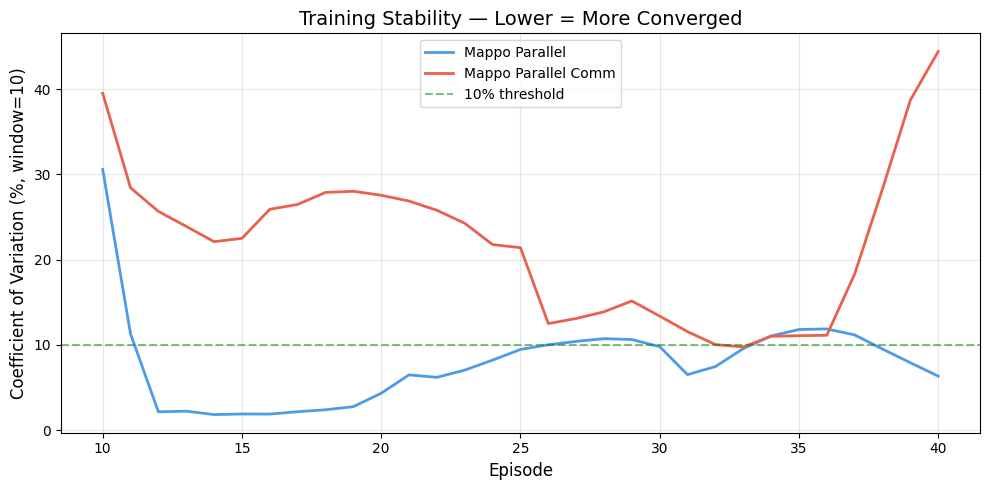

In [62]:
# ── Plot: Convergence check — last N episodes stability ───────────────
fig, ax = plt.subplots(figsize=(10, 5))

for name, data in methods.items():
    train = np.array(data["train"])
    if len(train) < 5:
        continue
    # Rolling std as % of rolling mean (coefficient of variation)
    window = min(10, len(train) // 2)
    if window < 2:
        continue
    rolling_mean = np.convolve(train, np.ones(window)/window, mode='valid')
    rolling_std = np.array([train[i:i+window].std() for i in range(len(train) - window + 1)])
    cv = np.abs(rolling_std / np.where(rolling_mean == 0, 1, rolling_mean)) * 100
    episodes = np.arange(window, len(train) + 1)

    color = colors.get(name, "#333")
    label = labels.get(name, name)
    ax.plot(episodes, cv, color=color, linewidth=2, label=label)

ax.set_xlabel("Episode", fontsize=12)
ax.set_ylabel(f"Coefficient of Variation (%, window={window})", fontsize=12)
ax.set_title("Training Stability — Lower = More Converged", fontsize=14)
ax.axhline(y=10, color="green", linestyle="--", alpha=0.5, label="10% threshold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Volunteering Analysis
Hoe vaak volunteeren agents, hoe is de verdeling per agent, hoeveel fallbacks, en hoe verandert dit over training episodes?

In [63]:
# ── Parse volunteering data from eval logs ────────────────────────────
vol_metrics = {}  # method → { episodes, vol_rate, avg_volunteers, fallback_rate, agent_vol_counts }

for method_name in methods:
    eval_dir = os.path.join(EXPERIMENT_DIR, method_name, "logs", "eval")
    if not os.path.isdir(eval_dir):
        for sd in os.listdir(os.path.join(EXPERIMENT_DIR, method_name)):
            candidate = os.path.join(EXPERIMENT_DIR, method_name, sd, "logs", "eval")
            if os.path.isdir(candidate):
                eval_dir = candidate
                break
    if not os.path.isdir(eval_dir):
        continue

    ep_data = defaultdict(lambda: {
        "vol_rate": [], "avg_n_vol": [], "fallback_rate": [],
        "assignment_types": [], "agent_vol_counts": [],
    })

    for fname in sorted(os.listdir(eval_dir)):
        if not fname.endswith(".csv"):
            continue
        m = re.match(r"log_eval_ep(\d+)_e(\d+)_", fname)
        if not m:
            continue
        ep_nr = int(m.group(1))

        df = pd.read_csv(os.path.join(eval_dir, fname), dtype={"task_volunteers": str})
        if df.empty:
            continue

        # Parse volunteer counts per task
        def count_volunteers(vol_str):
            if pd.isna(vol_str) or vol_str.strip() == "":
                return 0
            return len(str(vol_str).split("|"))

        def get_volunteer_ids(vol_str):
            if pd.isna(vol_str) or vol_str.strip() == "":
                return []
            return [v.strip() for v in str(vol_str).split("|") if v.strip()]

        df["_n_volunteers"] = df["task_volunteers"].apply(count_volunteers)

        # Volunteer rate: % of tasks with at least 1 volunteer
        has_vol = (df["_n_volunteers"] > 0).mean() * 100
        avg_n_vol = df["_n_volunteers"].mean()

        # Fallback rate: % of tasks assigned via fallback
        fallback_mask = df["task_assignment_type"].str.contains("fallback", case=False, na=False)
        fallback_rate = fallback_mask.mean() * 100

        # Assignment type distribution
        type_counts = df["task_assignment_type"].value_counts().to_dict()

        # Per-agent volunteer frequency
        all_vol_ids = []
        for vol_str in df["task_volunteers"]:
            all_vol_ids.extend(get_volunteer_ids(vol_str))
        agent_vol_freq = pd.Series(all_vol_ids).value_counts().to_dict() if all_vol_ids else {}

        ep_data[ep_nr]["vol_rate"].append(has_vol)
        ep_data[ep_nr]["avg_n_vol"].append(avg_n_vol)
        ep_data[ep_nr]["fallback_rate"].append(fallback_rate)
        ep_data[ep_nr]["assignment_types"].append(type_counts)
        ep_data[ep_nr]["agent_vol_counts"].append(agent_vol_freq)

    episodes_sorted = sorted(ep_data.keys())
    vol_metrics[method_name] = {
        "episodes": episodes_sorted,
        "vol_rate": [np.mean(ep_data[e]["vol_rate"]) for e in episodes_sorted],
        "avg_n_vol": [np.mean(ep_data[e]["avg_n_vol"]) for e in episodes_sorted],
        "fallback_rate": [np.mean(ep_data[e]["fallback_rate"]) for e in episodes_sorted],
        "assignment_types": {e: ep_data[e]["assignment_types"] for e in episodes_sorted},
        "agent_vol_counts": {e: ep_data[e]["agent_vol_counts"] for e in episodes_sorted},
    }
    print(f"  {method_name}: vol_rate {vol_metrics[method_name]['vol_rate'][-1]:.1f}%, "
          f"avg_volunteers {vol_metrics[method_name]['avg_n_vol'][-1]:.2f}, "
          f"fallback {vol_metrics[method_name]['fallback_rate'][-1]:.1f}%")

  mappo_parallel: vol_rate 0.0%, avg_volunteers 0.00, fallback 100.0%
  mappo_parallel_comm: vol_rate 81.0%, avg_volunteers 2.43, fallback 19.0%


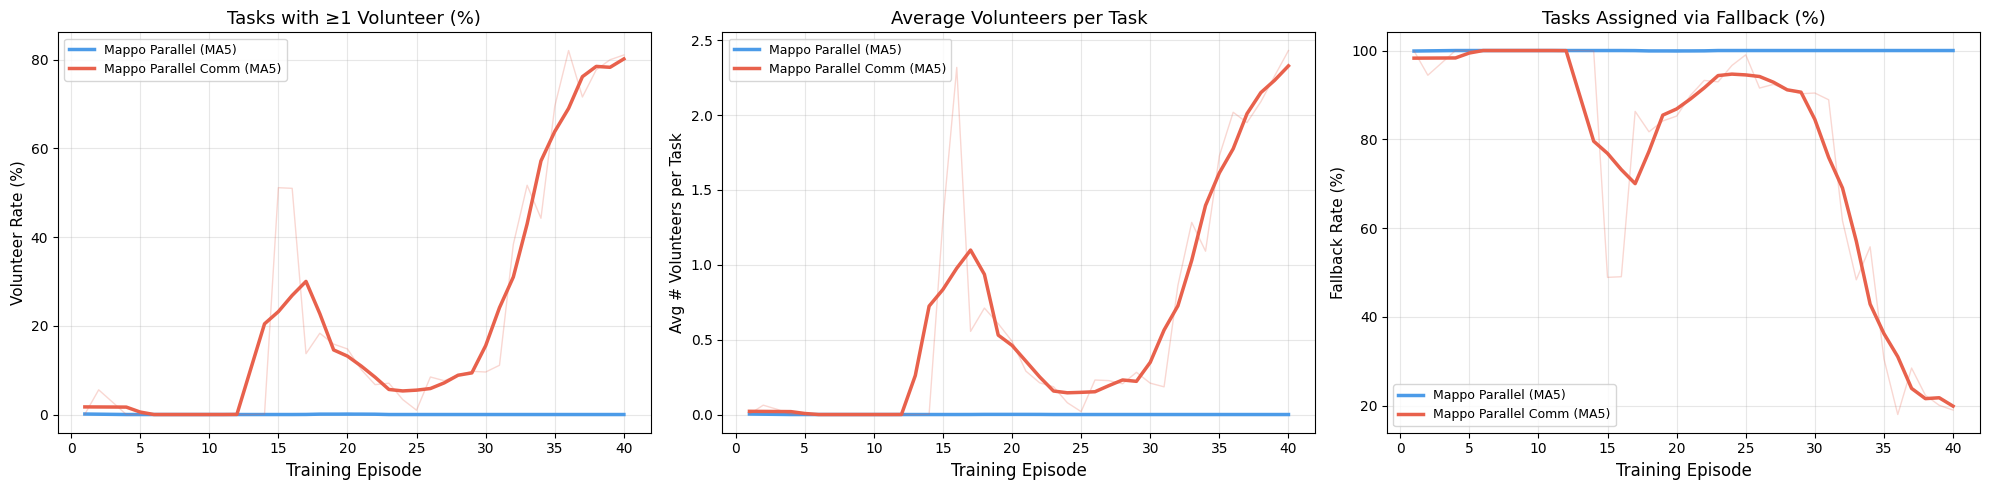

In [64]:
# ── Plot: Volunteer rate, avg volunteers, and fallback rate over episodes ──
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

vol_plot_configs = [
    ("vol_rate",     "Volunteer Rate (%)",         "Tasks with ≥1 Volunteer (%)"),
    ("avg_n_vol",    "Avg # Volunteers per Task",  "Average Volunteers per Task"),
    ("fallback_rate","Fallback Rate (%)",           "Tasks Assigned via Fallback (%)"),
]

for ax, (metric_key, ylabel, title) in zip(axes, vol_plot_configs):
    for method_name, vdata in vol_metrics.items():
        eps = np.array(vdata["episodes"])
        vals = np.array(vdata[metric_key])
        color = colors.get(method_name, "#333")
        label = labels.get(method_name, method_name)

        ax.plot(eps, vals, alpha=0.25, color=color, linewidth=1)
        if SMOOTH_WINDOW > 1 and len(vals) >= SMOOTH_WINDOW:
            ax.plot(eps, smooth(vals, SMOOTH_WINDOW), color=color,
                    linewidth=2.5, label=f"{label} (MA{SMOOTH_WINDOW})")
        else:
            ax.plot(eps, vals, color=color, linewidth=2, label=label)

    ax.set_xlabel("Training Episode", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

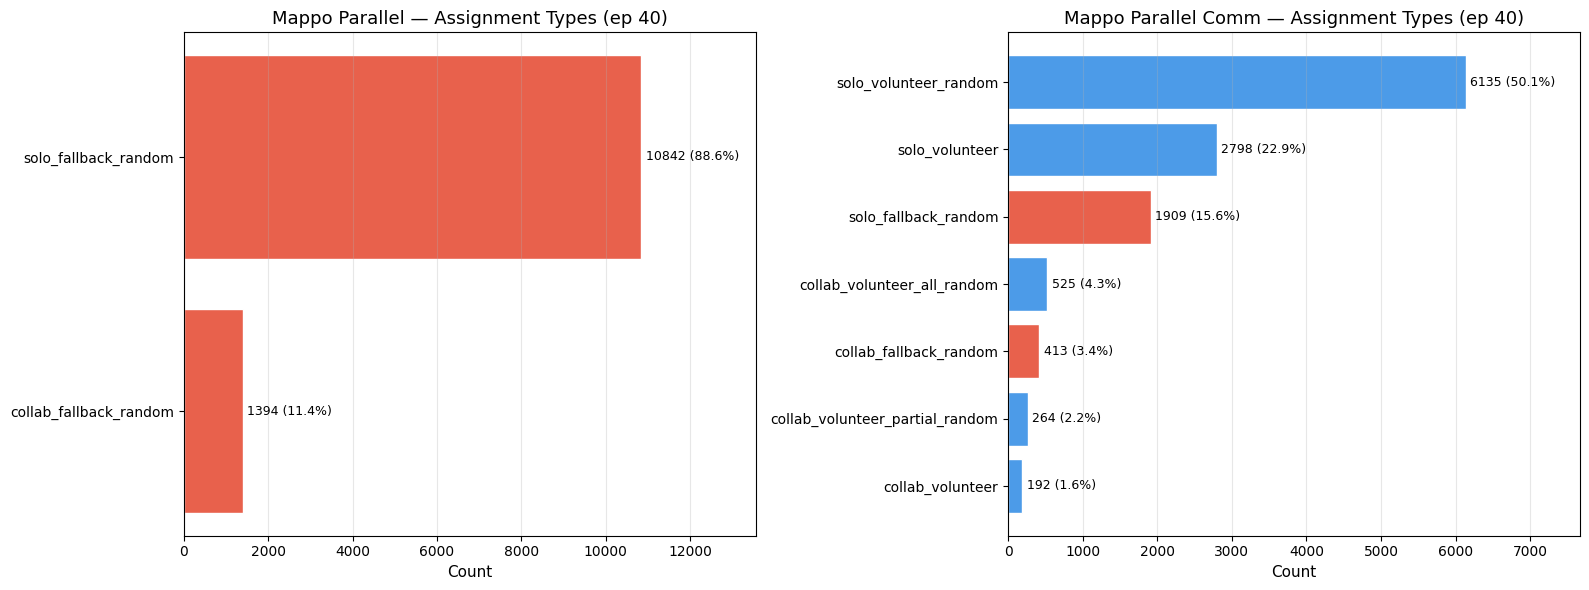

In [65]:
# ── Plot: Assignment type distribution (last eval episode) ────────────
fig, axes = plt.subplots(1, len(vol_metrics), figsize=(8 * len(vol_metrics), 6))
if len(vol_metrics) == 1:
    axes = [axes]

for ax, (method_name, vdata) in zip(axes, vol_metrics.items()):
    last_ep = vdata["episodes"][-1]
    # Merge assignment type counts across eval runs for last episode
    merged_types = defaultdict(int)
    for type_dict in vdata["assignment_types"][last_ep]:
        for atype, count in type_dict.items():
            merged_types[atype] += count

    # Sort by count descending
    sorted_types = sorted(merged_types.items(), key=lambda x: x[1], reverse=True)
    type_names = [t[0] for t in sorted_types]
    type_counts = [t[1] for t in sorted_types]
    total = sum(type_counts)

    # Color by category
    bar_colors = []
    for name in type_names:
        if "fallback" in name.lower():
            bar_colors.append("#E8614C")
        elif "volunteer" in name.lower():
            bar_colors.append("#4C9BE8")
        else:
            bar_colors.append("#888888")

    bars = ax.barh(range(len(type_names)), type_counts, color=bar_colors, edgecolor="white")
    ax.set_yticks(range(len(type_names)))
    ax.set_yticklabels(type_names, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel("Count", fontsize=11)
    ax.set_title(f"{labels.get(method_name, method_name)} — Assignment Types (ep {last_ep})", fontsize=13)

    # Add percentage labels
    for i, (count, bar) in enumerate(zip(type_counts, bars)):
        pct = count / total * 100
        ax.text(bar.get_width() + max(type_counts) * 0.01, bar.get_y() + bar.get_height() / 2,
                f"{count} ({pct:.1f}%)", va="center", fontsize=9)

    ax.set_xlim(0, max(type_counts) * 1.25)
    ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

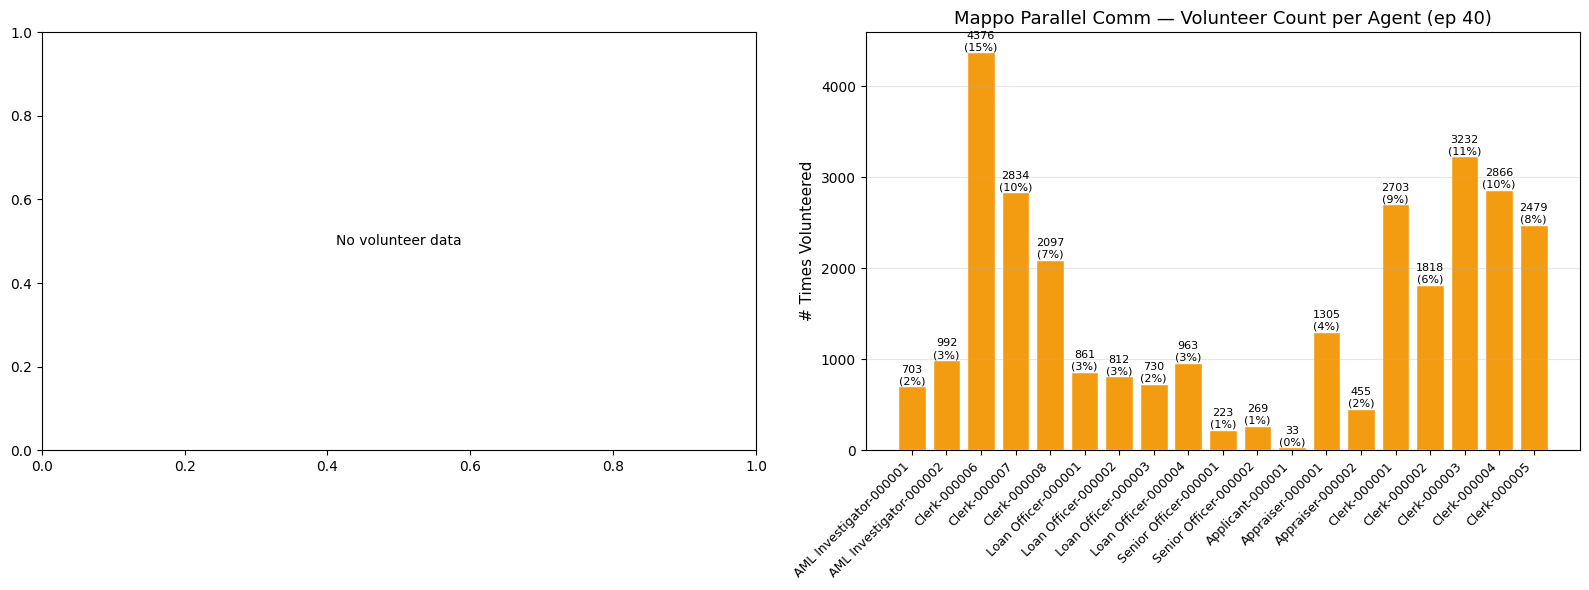

In [66]:
# ── Plot: Per-agent volunteer frequency (last eval episode) ───────────
fig, axes = plt.subplots(1, len(vol_metrics), figsize=(8 * len(vol_metrics), 6))
if len(vol_metrics) == 1:
    axes = [axes]

for ax, (method_name, vdata) in zip(axes, vol_metrics.items()):
    last_ep = vdata["episodes"][-1]
    # Merge agent volunteer counts across eval runs for last episode
    merged_agent_vols = defaultdict(int)
    for agent_dict in vdata["agent_vol_counts"][last_ep]:
        for agent_id, count in agent_dict.items():
            merged_agent_vols[str(agent_id)] += count

    if not merged_agent_vols:
        ax.text(0.5, 0.5, "No volunteer data", ha="center", va="center", transform=ax.transAxes)
        continue

    # Sort by agent name/id for consistent ordering
    sorted_agents = sorted(merged_agent_vols.items(), key=lambda x: x[0])
    agent_names = [a[0] for a in sorted_agents]
    agent_counts = [a[1] for a in sorted_agents]
    total_vol = sum(agent_counts)

    # Try to get agent names from the eval logs
    eval_dir = os.path.join(EXPERIMENT_DIR, method_name, "logs", "eval")
    if not os.path.isdir(eval_dir):
        for sd in os.listdir(os.path.join(EXPERIMENT_DIR, method_name)):
            candidate = os.path.join(EXPERIMENT_DIR, method_name, sd, "logs", "eval")
            if os.path.isdir(candidate):
                eval_dir = candidate
                break

    # Build agent_id → name mapping from a log file
    agent_id_to_name = {}
    try:
        sample_file = [f for f in os.listdir(eval_dir) if f.endswith(".csv")][0]
        sample_df = pd.read_csv(os.path.join(eval_dir, sample_file), dtype={"task_volunteers": str})
        for _, row in sample_df.iterrows():
            if pd.notna(row.get("task_agent_id")) and pd.notna(row.get("task_agent_name")):
                ids = str(row["task_agent_id"]).split("|")
                names = str(row["task_agent_name"]).split("|")
                for aid, aname in zip(ids, names):
                    agent_id_to_name[aid.strip()] = aname.strip()
    except Exception:
        pass

    # Use agent names if available
    display_names = [agent_id_to_name.get(aid, f"Agent {aid}") for aid in agent_names]

    bar_colors = ["#4C9BE8" if "Technician" in dn else "#2ECC71" if "Pharmacist" in dn
                  else "#F39C12" for dn in display_names]

    bars = ax.bar(range(len(display_names)), agent_counts, color=bar_colors, edgecolor="white")
    ax.set_xticks(range(len(display_names)))
    ax.set_xticklabels(display_names, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("# Times Volunteered", fontsize=11)
    ax.set_title(f"{labels.get(method_name, method_name)} — Volunteer Count per Agent (ep {last_ep})", fontsize=13)

    # Add count labels on bars
    for bar, count in zip(bars, agent_counts):
        pct = count / total_vol * 100
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"{count}\n({pct:.0f}%)", ha="center", va="bottom", fontsize=8)

    ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

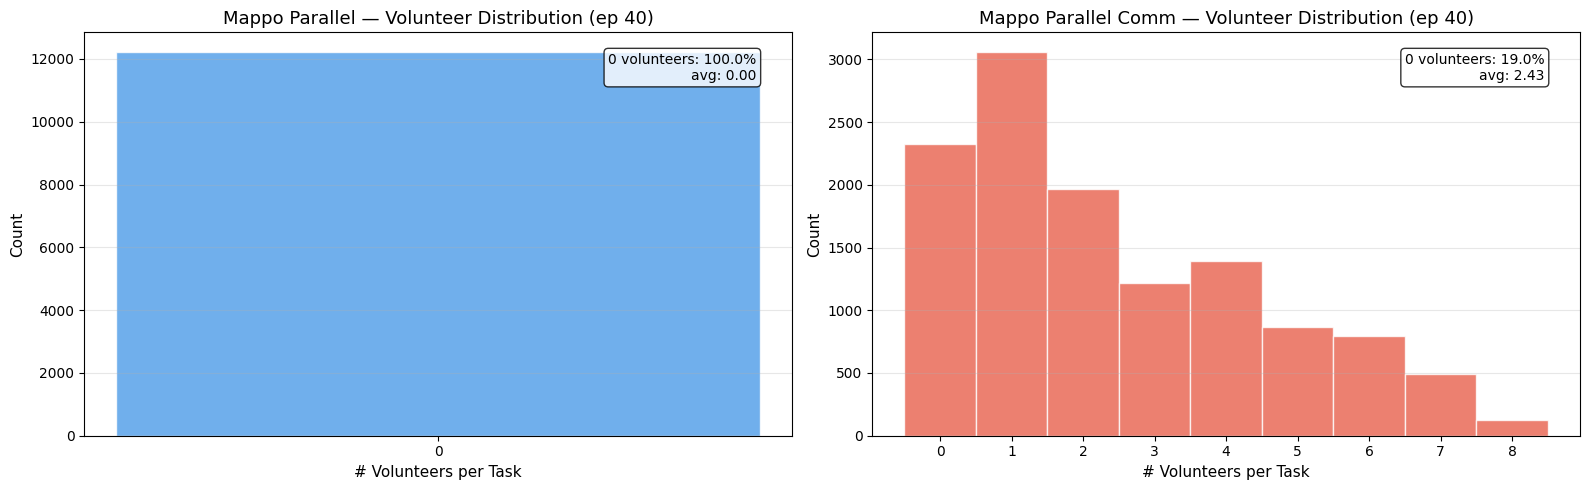

In [67]:
# ── Plot: Volunteer distribution — histogram of #volunteers per task (last ep) ──
fig, axes = plt.subplots(1, len(vol_metrics), figsize=(8 * len(vol_metrics), 5))
if len(vol_metrics) == 1:
    axes = [axes]

for ax, (method_name, vdata) in zip(axes, vol_metrics.items()):
    last_ep = vdata["episodes"][-1]

    # Re-read the last episode eval logs for the histogram
    eval_dir = os.path.join(EXPERIMENT_DIR, method_name, "logs", "eval")
    if not os.path.isdir(eval_dir):
        for sd in os.listdir(os.path.join(EXPERIMENT_DIR, method_name)):
            candidate = os.path.join(EXPERIMENT_DIR, method_name, sd, "logs", "eval")
            if os.path.isdir(candidate):
                eval_dir = candidate
                break

    all_n_vols = []
    for fname in sorted(os.listdir(eval_dir)):
        if not fname.endswith(".csv"):
            continue
        m_file = re.match(r"log_eval_ep(\d+)_e(\d+)_", fname)
        if not m_file or int(m_file.group(1)) != last_ep:
            continue
        df = pd.read_csv(os.path.join(eval_dir, fname), dtype={"task_volunteers": str})
        n_vols = df["task_volunteers"].apply(
            lambda v: 0 if pd.isna(v) or str(v).strip() == "" else len(str(v).split("|"))
        )
        all_n_vols.extend(n_vols.tolist())

    if not all_n_vols:
        continue

    max_vol = max(all_n_vols)
    bins = np.arange(-0.5, max_vol + 1.5, 1)
    ax.hist(all_n_vols, bins=bins, color=colors.get(method_name, "#333"),
            edgecolor="white", alpha=0.8)
    ax.set_xlabel("# Volunteers per Task", fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.set_title(f"{labels.get(method_name, method_name)} — Volunteer Distribution (ep {last_ep})", fontsize=13)
    ax.set_xticks(range(0, max_vol + 1))

    # Add stats
    n_zero = all_n_vols.count(0)
    pct_zero = n_zero / len(all_n_vols) * 100
    avg = np.mean(all_n_vols)
    ax.text(0.95, 0.95, f"0 volunteers: {pct_zero:.1f}%\navg: {avg:.2f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

In [68]:
# ── Summary table: volunteering stats ─────────────────────────────────
vol_rows = []
for method_name, vdata in vol_metrics.items():
    last_ep = vdata["episodes"][-1]
    first_ep = vdata["episodes"][0]

    # Aggregate assignment types for last episode
    merged_types = defaultdict(int)
    for type_dict in vdata["assignment_types"][last_ep]:
        for atype, count in type_dict.items():
            merged_types[atype] += count
    total_tasks = sum(merged_types.values())

    fallback_count = sum(v for k, v in merged_types.items() if "fallback" in k.lower())
    volunteer_count = sum(v for k, v in merged_types.items() if "volunteer" in k.lower())

    vol_rows.append({
        "method": labels.get(method_name, method_name),
        "vol_rate_first (%)": f"{vdata['vol_rate'][0]:.1f}",
        "vol_rate_last (%)": f"{vdata['vol_rate'][-1]:.1f}",
        "avg_vol_first": f"{vdata['avg_n_vol'][0]:.2f}",
        "avg_vol_last": f"{vdata['avg_n_vol'][-1]:.2f}",
        "fallback_first (%)": f"{vdata['fallback_rate'][0]:.1f}",
        "fallback_last (%)": f"{vdata['fallback_rate'][-1]:.1f}",
        "total_tasks (last)": total_tasks,
        "volunteer_tasks": volunteer_count,
        "fallback_tasks": fallback_count,
    })

vol_summary = pd.DataFrame(vol_rows).set_index("method")
print("=" * 120)
print("VOLUNTEERING SUMMARY")
print("=" * 120)
display(vol_summary)

VOLUNTEERING SUMMARY


,vol_rate_first (%),vol_rate_last (%),avg_vol_first,avg_vol_last,fallback_first (%),fallback_last (%),total_tasks (last),volunteer_tasks,fallback_tasks
method,,,,,,,,,
Mappo Parallel,0.2,0.0,0.01,0.00,99.8,100.0,12236,0,12236
Mappo Parallel Comm,0.1,81.0,0.00,2.43,99.9,19.0,12236,9914,2322
